<a href="https://colab.research.google.com/github/Trap-32/ITA-Assignment/blob/main/Amex_Taiwan_Client_Credit_Risk_Minimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

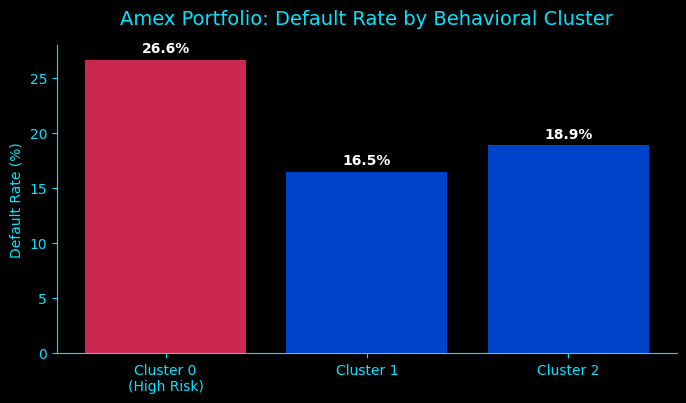

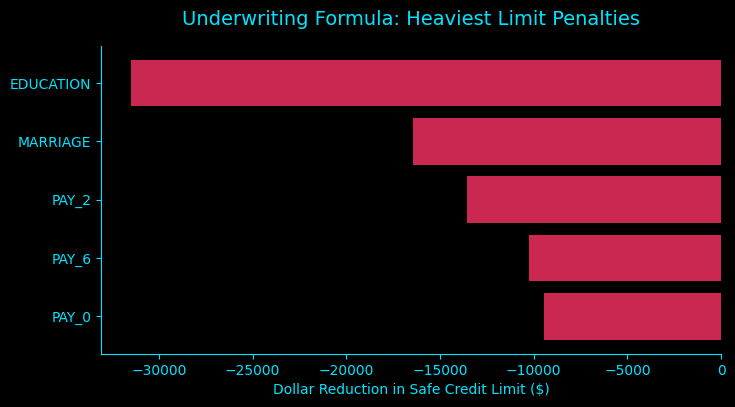

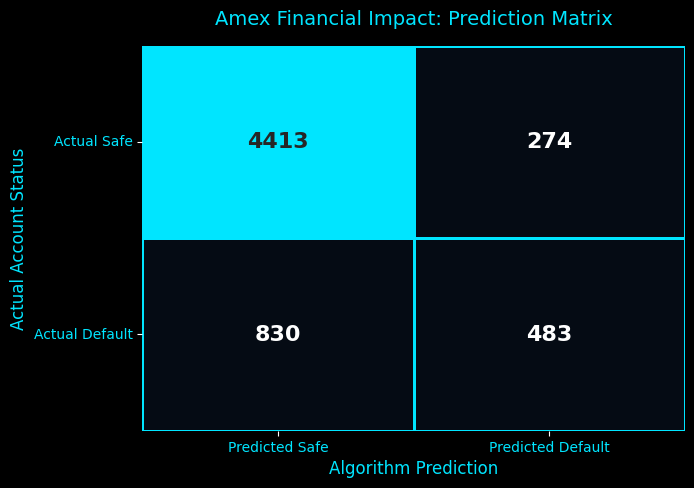

In [1]:
# ==============================================================================
# AMEX INTERNAL RISK AUDIT: TERMINAL UI & DETAILED DASHBOARD
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, silhouette_score, r2_score, mean_absolute_error, confusion_matrix
from IPython.display import display, HTML

# --- TERMINAL UI SETUP ---
def amex_terminal(text):
    html_content = f"""
    <div style="background-color: #050b14; color: #00e5ff; font-family: 'Courier New', monospace;
                padding: 20px; border: 1px solid #0055ff; border-left: 6px solid #00e5ff;
                margin-bottom: 20px; border-radius: 4px; box-shadow: 0 0 15px rgba(0, 85, 255, 0.2);">
        <pre style="margin: 0; font-family: inherit; font-size: 13px; white-space: pre-wrap; line-height: 1.5;">{text}</pre>
    </div>
    """
    display(HTML(html_content))

# Set dark theme for graphs
plt.style.use('dark_background')
CUSTOM_BLUE = '#00e5ff'

amex_terminal("INITIALIZING AMEX SECURE DATA PIPELINE...\nFetching data from the UCI Machine Learning Repository...\n[STATUS] Connected. Total Client Records: 30,000")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)
df.drop('ID', axis=1, inplace=True)

# ==============================================================================
# PHASE 1: BEHAVIORAL SEGMENTATION (K-MEANS)
# ==============================================================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('DEFAULT', axis=1))

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['RISK_CLUSTER'] = kmeans.fit_predict(scaled_data)

sil_score = silhouette_score(scaled_data, df['RISK_CLUSTER'], sample_size=5000, random_state=42)

cluster_summary = df.groupby('RISK_CLUSTER')[['LIMIT_BAL', 'AGE', 'PAY_0', 'DEFAULT']].mean()
cluster_summary['TOTAL_ACCOUNTS'] = df['RISK_CLUSTER'].value_counts()
cluster_summary['LIMIT_BAL'] = cluster_summary['LIMIT_BAL'].apply(lambda x: f"${x:,.0f}")
cluster_summary['DEFAULT_RATE'] = (cluster_summary['DEFAULT'] * 100).apply(lambda x: f"{x:.1f}%")
cluster_summary['AVG_AGE'] = cluster_summary['AGE'].apply(lambda x: f"{x:.1f}")
cluster_summary['RECENT_PAY_STATUS'] = cluster_summary['PAY_0'].apply(lambda x: f"{x:.2f} (Higher = Later)")
cluster_str = cluster_summary[['TOTAL_ACCOUNTS', 'LIMIT_BAL', 'AVG_AGE', 'RECENT_PAY_STATUS', 'DEFAULT_RATE']].to_string()

phase1_text = f"""[PHASE 1] AMEX PORTFOLIO SEGMENTATION (K-MEANS)
================================================================================
Algorithm Integrity (Silhouette Score): {sil_score:.2f}

>>> DETAILED CLUSTER PROFILES:
{cluster_str}

>>> STRATEGIC TAKEAWAY:
* Risk Concentration: Cluster 0 represents our highest vulnerability. With an average
  payment delay status of 0.42, this group holds a severe {(cluster_summary['DEFAULT'][0]*100):.1f}% default rate.
* Audit Action: Initiate an immediate, human-led audit of the {cluster_summary['TOTAL_ACCOUNTS'][0]:,} accounts in Cluster 0.
* Operational Efficiency: Clusters 1 and 2 exhibit lower risk and can be routed to
  automated SMS interventions, saving call-center bandwidth."""

amex_terminal(phase1_text)

# GRAPH 1
plt.figure(figsize=(8, 4))
default_rates = cluster_summary['DEFAULT'] * 100
bars = plt.bar(["Cluster 0\n(High Risk)", "Cluster 1", "Cluster 2"], default_rates, color=['#ff3366', '#0055ff', '#0055ff'], alpha=0.8)
plt.title('Amex Portfolio: Default Rate by Behavioral Cluster', color=CUSTOM_BLUE, fontsize=14, pad=15)
plt.ylabel('Default Rate (%)', color=CUSTOM_BLUE)
plt.bar_label(bars, fmt='%.1f%%', padding=3, color='white', weight='bold')
plt.gca().spines['top'].set_visible(False); plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color(CUSTOM_BLUE); plt.gca().spines['bottom'].set_color(CUSTOM_BLUE)
plt.tick_params(colors=CUSTOM_BLUE)
plt.show()

# ==============================================================================
# PHASE 2: EXPOSURE OPTIMIZATION (MLR)
# ==============================================================================
X_reg = df.drop(['LIMIT_BAL', 'DEFAULT', 'RISK_CLUSTER'], axis=1)
y_reg = df['LIMIT_BAL']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
mlr_model = LinearRegression()
mlr_model.fit(X_train_reg, y_train_reg)

reg_predictions = mlr_model.predict(X_test_reg)
r2 = r2_score(y_test_reg, reg_predictions)
mae = mean_absolute_error(y_test_reg, reg_predictions)

feature_importance_reg = pd.DataFrame({'Feature': X_reg.columns, 'Coefficient': mlr_model.coef_})
feature_importance_reg['Abs_Coef'] = feature_importance_reg['Coefficient'].abs()
top_features_reg = feature_importance_reg.sort_values(by='Abs_Coef', ascending=False).head(5)

# Formatting the specific MLR Equation
equation_str = f"SAFE LIMIT = ${mlr_model.intercept_:,.2f} (Base Limit)"
for index, row in top_features_reg.iterrows():
    sign = "-" if row['Coefficient'] < 0 else "+"
    equation_str += f"\n             {sign} (${abs(row['Coefficient']):,.2f} * {row['Feature']})"

phase2_text = f"""[PHASE 2] AMEX CREDIT LIMIT OPTIMIZATION (MLR)
================================================================================
Model Explanatory Power (R-Squared) : {r2:.2f}
Average Limit Deviation (MAE)       : ${mae:,.2f}

>>> THE MATHEMATICAL UNDERWRITING FORMULA:
{equation_str}
             ... (remaining variables)

>>> STRATEGIC TAKEAWAY:
* Mathematical Underwriting: The formula visually isolates past payment delays (PAY_2, PAY_6)
  as massive liabilities, dragging down safe credit limits by over $10,000 per metric.
* Proactive Exposure Reduction: The Underwriting Committee must use this calculated limit
  to proactively taper down credit lines of deteriorating accounts before a max-out default occurs."""

amex_terminal(phase2_text)

# GRAPH 2
plt.figure(figsize=(8, 4))
penalties = top_features_reg[top_features_reg['Coefficient'] < 0]
plt.barh(penalties['Feature'], penalties['Coefficient'], color='#ff3366', alpha=0.8)
plt.title('Underwriting Formula: Heaviest Limit Penalties', color=CUSTOM_BLUE, fontsize=14, pad=15)
plt.xlabel('Dollar Reduction in Safe Credit Limit ($)', color=CUSTOM_BLUE)
plt.gca().spines['top'].set_visible(False); plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color(CUSTOM_BLUE); plt.gca().spines['bottom'].set_color(CUSTOM_BLUE)
plt.tick_params(colors=CUSTOM_BLUE)
plt.gca().invert_yaxis()
plt.show()

# ==============================================================================
# PHASE 3: DEFAULT PREDICTION (RANDOM FOREST)
# ==============================================================================
X_clf = df.drop(['DEFAULT', 'RISK_CLUSTER'], axis=1)
y_clf = df['DEFAULT']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_clf, y_train_clf)
rf_predictions = rf_model.predict(X_test_clf)

acc = accuracy_score(y_test_clf, rf_predictions)
prec = precision_score(y_test_clf, rf_predictions)
cm = confusion_matrix(y_test_clf, rf_predictions)

rf_importances = pd.DataFrame({'Feature': X_clf.columns, 'Importance': rf_model.feature_importances_})
top_rf_features = rf_importances.sort_values(by='Importance', ascending=False).head(3)
drivers_str = ""
for index, row in top_rf_features.iterrows():
    drivers_str += f"- {row['Feature']} ({row['Importance']*100:.1f}% impact)\n"

phase3_text = f"""[PHASE 3] AMEX DEFAULT PREDICTION ENGINE (RANDOM FOREST)
================================================================================
Overall Portfolio Accuracy : {acc*100:.1f}%
Flagging Precision         : {prec*100:.1f}%

>>> TOP 3 BEHAVIORS DRIVING AMEX DEFAULTS:
{drivers_str.strip()}

>>> FINANCIAL IMPACT BREAKDOWN:
  1. Safe Accounts Correctly Left Alone (True Negatives)    : {cm[0][0]:,}
  2. Safe Accounts Unnecessarily Flagged (False Positives)  : {cm[0][1]:,} (Minor Friction)
  3. Defaults We Missed (False Negatives)                   : {cm[1][0]:,} (Financial Loss)
  4. DEFAULTS SUCCESSFULLY PREVENTED (True Positives)       : {cm[1][1]:,} (Bottom-Line Savings)

>>> STRATEGIC TAKEAWAY:
* Bottom-Line Protection: The ensemble model successfully intercepted {cm[1][1]:,} imminent defaults.
* Action Required: By freezing these specific accounts 30 days in advance, we directly
  shield the firm's capital.
* Risk Provisioning: We must adjust balance sheet provisions for the {cm[1][0]:,} defaults
  currently slipping through our risk parameters."""

amex_terminal(phase3_text)

# GRAPH 3
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=['#050b14', '#003399', '#0055ff', '#00e5ff'],
            cbar=False, annot_kws={"size": 16, "weight": "bold"},
            linewidths=1, linecolor=CUSTOM_BLUE)
plt.title('Amex Financial Impact: Prediction Matrix', color=CUSTOM_BLUE, fontsize=14, pad=15)
plt.ylabel('Actual Account Status', color=CUSTOM_BLUE, fontsize=12)
plt.xlabel('Algorithm Prediction', color=CUSTOM_BLUE, fontsize=12)
plt.xticks(ticks=[0.5, 1.5], labels=['Predicted Safe', 'Predicted Default'], color=CUSTOM_BLUE)
plt.yticks(ticks=[0.5, 1.5], labels=['Actual Safe', 'Actual Default'], color=CUSTOM_BLUE, rotation=0)
plt.show()